In [1]:
try:
    import datasets
    print("The 'datasets' library is already installed.")
except ImportError:
    print("The 'datasets' library is not installed. Installing it now...")
    !pip install datasets
    print("The 'datasets' library has been installed.")


The 'datasets' library is not installed. Installing it now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 22.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.


In [2]:
import pandas as pd


In [3]:
# Define the file paths
file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/complex_text.txt'
file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simple_text.txt'

In [4]:
# Reading the content of both files, specifying the encoding
with open(file_path_original, 'r', encoding='latin-1') as original_file:  # Try 'latin-1' first
    original_text = original_file.read()

with open(file_path_simple, 'r', encoding='latin-1') as simple_file:  # Try 'latin-1' for consistency
    simple_text = simple_file.read()

In [5]:
# Split the original and simple text into lines to prepare for storing them in a dataframe
original_lines = original_text.splitlines()
simple_lines = simple_text.splitlines()

# Removing empty lines from both texts
original_lines_cleaned = [line for line in original_lines if line.strip() != '']
simple_lines_cleaned = [line for line in simple_lines if line.strip() != '']

In [6]:
# Pad the shorter list (simple_lines_cleaned) with empty strings to match the length of the original_lines_cleaned
while len(simple_lines_cleaned) < len(original_lines_cleaned):
    simple_lines_cleaned.append('')

# Create a dataframe with two columns: 'Original' and 'Simple'
data = {
    "Original": original_lines_cleaned,
    "Simple": simple_lines_cleaned
}

In [7]:
df = pd.DataFrame(data)
df = df.iloc[:-12]
df.head()

,Original,Simple
0,The patient presented with a history of chroni...,The patient came in with worsening COPD sympto...
1,The patient was diagnosed with type 2 diabetes...,The patient was diagnosed with type 2 diabetes...
2,A 45-year-old male presented to the emergency ...,A 45-year-old man came to the emergency room w...
3,"The patient, a 62-year-old female, presented w...",A 62-year-old woman came in with worsening low...
4,"The patient, a 50-year-old male with a history...",A 50-year-old man with a history of high blood...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Original  261 non-null    object
 1   Simple    261 non-null    object
dtypes: object(2)
memory usage: 4.2+ KB


In [9]:
for i in range(5):
  print('Actual :' ,df.iloc[i,0])
  print('-----' * 50)
  print('Simple :', df.iloc[i,1])
  print('-----' * 50)

Actual : The patient presented with a history of chronic obstructive pulmonary disease (COPD) exacerbation, accompanied by increased dyspnea, wheezing, and productive cough. Despite previous treatment with bronchodilators and corticosteroids, the symptoms had worsened over the past week. On examination, the patient had a respiratory rate of 28 breaths per minute, and oxygen saturation was 88% on room air. Auscultation revealed bilateral wheezing and diminished breath sounds. A chest X-ray was ordered to rule out pneumonia, and the patient was started on antibiotics and supplemental oxygen. The decision was made to admit the patient for further observation and management of the acute COPD exacerbation.
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Simple : The patient came in with wors

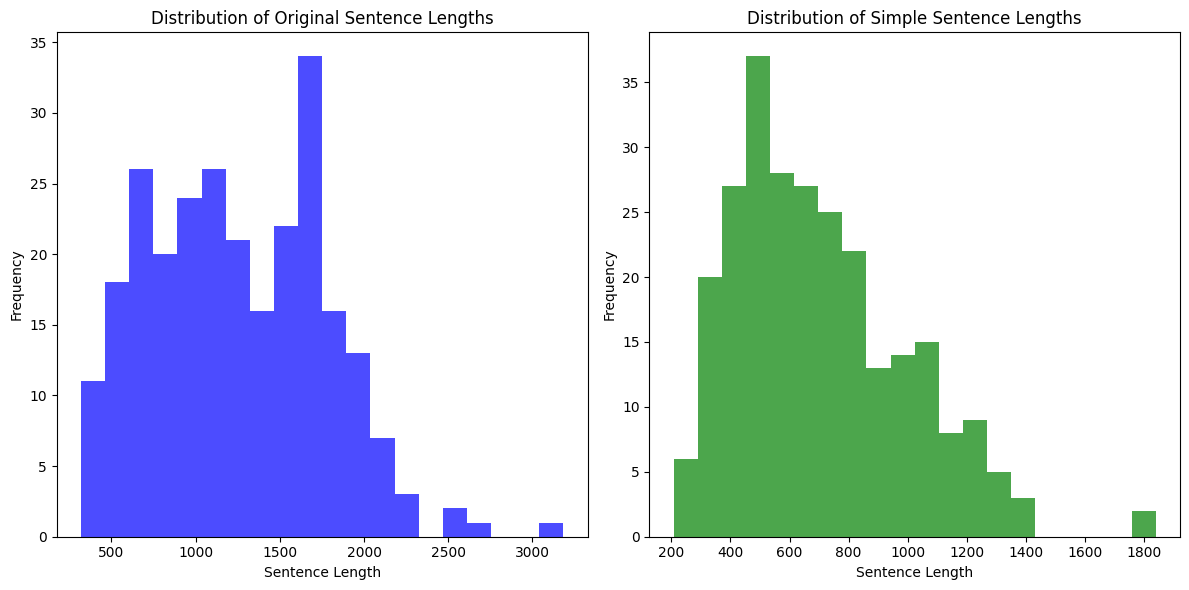

In [10]:

import matplotlib.pyplot as plt

# Calculate the length of each sentence in both columns
df['Original Length'] = df['Original'].apply(len)
df['Simple Length'] = df['Simple'].apply(len)

# Plot the histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['Original Length'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Original Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Simple Length'], bins=20, color='green', alpha=0.7)
plt.title('Distribution of Simple Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


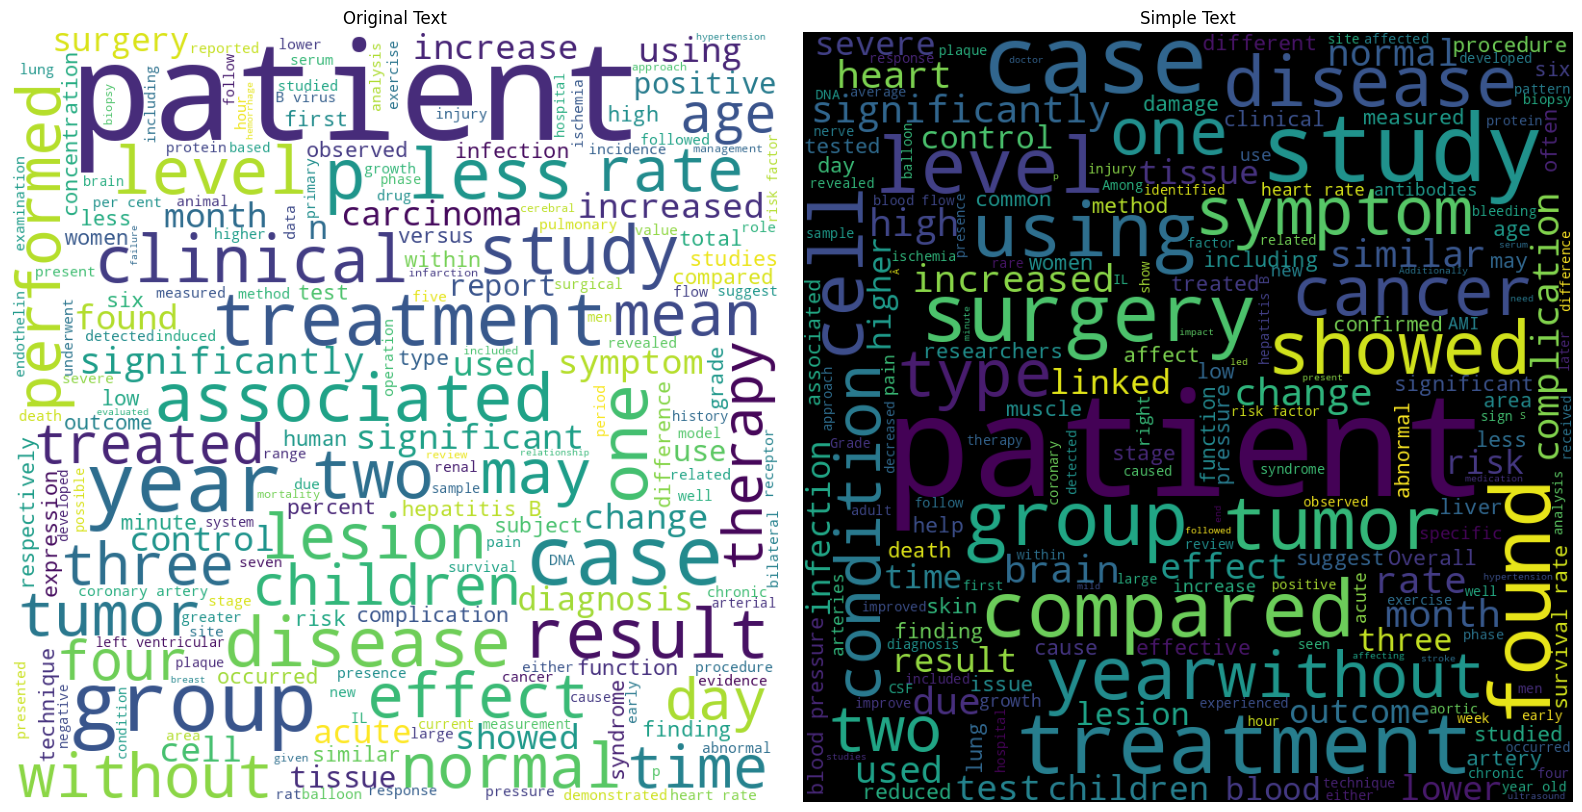

In [11]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Create stopwords
stopwords = set(STOPWORDS)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot word cloud for 'Original' column
wordcloud_original = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Original']))

axs[0].imshow(wordcloud_original)
axs[0].axis("off")
axs[0].set_title('Original Text')

# Plot word cloud for 'Simple' column
wordcloud_simple = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Simple']))

axs[1].imshow(wordcloud_simple)
axs[1].axis("off")
axs[1].set_title('Simple Text')

plt.tight_layout()
plt.show()


In [12]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import pandas as pd
from datasets import Dataset as HFDataset
from transformers import BartTokenizer, BartForConditionalGeneration, DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
import torch


In [13]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [14]:
def preprocess_text(text):
    lemmatizer, stop_words = WordNetLemmatizer(), set(stopwords.words('english'))
    return ' '.join(
        lemmatizer.lemmatize(w, 'a' if t.startswith('J') else 'v' if t.startswith('V') else 'n' if t.startswith('N') else 'r' if t.startswith('R') else 'n')
        for w, t in pos_tag(word_tokenize(text.lower())) if w.isalnum() and w not in stop_words
    )


In [15]:
# Prepare dataset from pandas DataFrame
def prepare_dataset(df):
    df['input_text'] = df['Original'].apply(preprocess_text)
    df['target_text'] = df['Simple'].apply(preprocess_text)
    data = {'input_text': df['input_text'].tolist(), 'target_text': df['target_text'].tolist()}
    return HFDataset.from_dict(data)

In [16]:
# Prepare and preprocess dataset
dataset = prepare_dataset(df)

# BART

In [17]:
# Tokenizer and Model
tokenizer = BartTokenizer.from_pretrained('facebook/bart-large')
model = BartForConditionalGeneration.from_pretrained('facebook/bart-large')




/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

In [18]:
# Tokenization function
def tokenize_function(examples):
    model_inputs = tokenizer(examples['input_text'], max_length=1024, truncation=True, padding='max_length')
    labels = tokenizer(examples['target_text'], max_length=1024, truncation=True, padding='max_length')
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

In [19]:
# Tokenize the dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dataloader = DataLoader(tokenized_dataset, batch_size=2, shuffle=True)

Map:   0%|          | 0/261 [00:00<?, ? examples/s]

In [20]:
# Training setup (as per your previous code)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)


In [21]:
import matplotlib.pyplot as plt

# Initialize an empty list to store losses
losses = []

In [22]:
# Training loop
num_epochs = 75
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    scheduler.step()
    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)  # Append the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")



Epoch 1/75, Loss: 6.7760
Epoch 2/75, Loss: 0.9891
Epoch 3/75, Loss: 0.4211
Epoch 4/75, Loss: 0.3620
Epoch 5/75, Loss: 0.3353
Epoch 6/75, Loss: 0.3196
Epoch 7/75, Loss: 0.2995
Epoch 8/75, Loss: 0.2885
Epoch 9/75, Loss: 0.2767
Epoch 10/75, Loss: 0.2649
Epoch 11/75, Loss: 0.2538
Epoch 12/75, Loss: 0.2476
Epoch 13/75, Loss: 0.3094
Epoch 14/75, Loss: 0.2348
Epoch 15/75, Loss: 0.2290
Epoch 16/75, Loss: 0.2170
Epoch 17/75, Loss: 0.2088
Epoch 18/75, Loss: 0.2022
Epoch 19/75, Loss: 0.1954
Epoch 20/75, Loss: 0.1881
Epoch 21/75, Loss: 0.1826
Epoch 22/75, Loss: 0.1757
Epoch 23/75, Loss: 0.1699
Epoch 24/75, Loss: 0.1648
Epoch 25/75, Loss: 0.1603
Epoch 26/75, Loss: 0.1538
Epoch 27/75, Loss: 0.1483
Epoch 28/75, Loss: 0.1496
Epoch 29/75, Loss: 0.1425
Epoch 30/75, Loss: 0.1375
Epoch 31/75, Loss: 0.1312
Epoch 32/75, Loss: 0.1359
Epoch 33/75, Loss: 0.1370
Epoch 34/75, Loss: 0.1246
Epoch 35/75, Loss: 0.1250
Epoch 36/75, Loss: 0.1187
Epoch 37/75, Loss: 0.1154
Epoch 38/75, Loss: 0.1209
Epoch 39/75, Loss: 0.

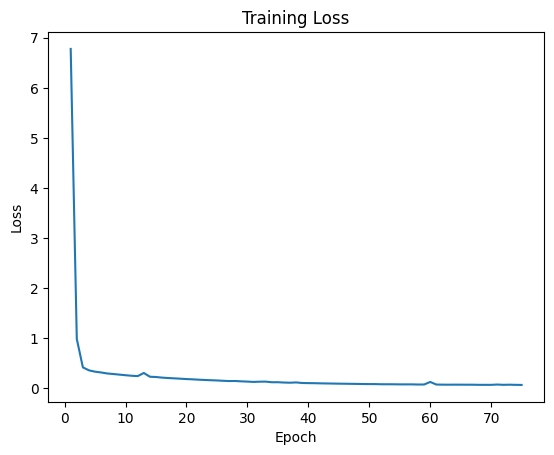

In [23]:
# Plotting the losses
plt.plot(range(1, num_epochs + 1), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [24]:
# Save the model and tokenizer
model.save_pretrained('/content/drive/MyDrive/MEDICAL/Model_res/simplification_model')
tokenizer.save_pretrained('/content/drive/MyDrive/MEDICAL/Model_res/simplification_model')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


('/content/drive/MyDrive/MEDICAL/Model_res/simplification_model/tokenizer_config.json',
 '/content/drive/MyDrive/MEDICAL/Model_res/simplification_model/special_tokens_map.json',
 '/content/drive/MyDrive/MEDICAL/Model_res/simplification_model/vocab.json',
 '/content/drive/MyDrive/MEDICAL/Model_res/simplification_model/merges.txt',
 '/content/drive/MyDrive/MEDICAL/Model_res/simplification_model/added_tokens.json')

In [25]:
try:
    import textstat
    print("The 'textstat' library is already installed.")
except ImportError:
    print("The 'textstat' library is not installed. Installing it now...")
    !pip install textstat
    print("The 'textstat' library has been installed.")


The 'textstat' library is not installed. Installing it now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 88.8 MB/s eta 0:00:00
The 'textstat' library has been installed.


In [26]:
try:
    import evaluate
    print("The 'evaluate' library is already installed.")
except ImportError:
    print("The 'evaluate' library is not installed. Installing it now...")
    !pip install evaluate
    print("The 'evaluate' library has been installed.")


The 'evaluate' library is not installed. Installing it now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.7 MB/s eta 0:00:00
The 'evaluate' library has been installed.


In [27]:
import torch
from transformers import BartTokenizer, BartForConditionalGeneration
from datasets import load_metric
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from textstat import flesch_kincaid_grade

In [28]:


# Download NLTK data
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [29]:
# from transformers import BartForConditionalGeneration, BartTokenizer

# # Load the model and tokenizer
# model_path = '/content/drive/MyDrive/MEDICAL/Model_res/simplification_model'
# model = BartForConditionalGeneration.from_pretrained(model_path)
# tokenizer = BartTokenizer.from_pretrained(model_path)

In [30]:

# import os
# for dirname, _, filenames in os.walk(model_path):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))


NameError: name 'model_path' is not defined

In [31]:
# Evaluation Functions
def evaluate_readability(text):
    fkgl = flesch_kincaid_grade(text)
    return fkgl



In [32]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


In [33]:
bert_score_metric = load_metric("bertscore", trust_remote_code=True)
meteor_metric = load_metric('meteor', trust_remote_code=True)

# Import BLEU and COMET
from datasets import load_metric

# Load BLEU and COMET metrics
bleu_metric = load_metric("bleu", trust_remote_code=True)


<ipython-input-33-728e94184190>:1: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  bert_score_metric = load_metric("bertscore", trust_remote_code=True)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [34]:
import evaluate

# Load BLEU and COMET metrics
bleu_metric = evaluate.load("bleu")


In [36]:
from nltk.translate.bleu_score import sentence_bleu

# Ensure you have downloaded the necessary NLTK data files
nltk.download('punkt')

def evaluate_metrics(pred_text, ref_text):
    # Readability score
    fkgl = evaluate_readability(pred_text)

    # BERTScore
    bert_score = bert_score_metric.compute(predictions=[pred_text], references=[ref_text], lang="en")

    # METEOR score
    meteor = meteor_metric.compute(predictions=[pred_text], references=[ref_text])['meteor']

    # BLEU score
    reference_tokens = nltk.word_tokenize(ref_text)
    prediction_tokens = nltk.word_tokenize(pred_text)
    bleu = sentence_bleu([reference_tokens], prediction_tokens)

    return fkgl, bert_score, meteor, bleu

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [37]:
# Define the file paths for your evaluation data
eval_file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/original_text.txt'
eval_file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simplified_text.txt'

In [38]:
# Load the evaluation data
with open(eval_file_path_original, 'r', encoding='latin-1') as original_file:
    eval_original_text = original_file.read()

with open(eval_file_path_simple, 'r', encoding='latin-1') as simple_file:
    eval_simple_text = simple_file.read()


In [39]:

# Split into lines and preprocess
eval_original_lines = eval_original_text.splitlines()
eval_simple_lines = eval_simple_text.splitlines()

# Preprocess the evaluation data (similar to training data)
eval_original_lines = [preprocess_text(line) for line in eval_original_lines]
eval_simple_lines = [preprocess_text(line) for line in eval_simple_lines]

In [40]:
def generate_simplified_text(complex_text):
    model.eval()
    inputs = tokenizer(complex_text, return_tensors='pt', max_length=1024, truncation=True)

    # Move input tensors to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    summary_ids = model.generate(inputs['input_ids'], max_length=1024, num_beams=4, early_stopping=True)
    simplified_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return simplified_text

In [41]:

# Initialize lists to store metric values
fkgl_scores = []
bert_scores = []
meteor_scores = []
bleu_scores = []

# Evaluate and store metrics for each pair of sentences
for original, simple in zip(eval_original_lines, eval_simple_lines):
    simplified_text = generate_simplified_text(original)

    fkgl, bert_score, meteor, bleu = evaluate_metrics(simplified_text, simple)

    fkgl_scores.append(fkgl)
    bert_scores.append(bert_score['f1'][0])
    meteor_scores.append(meteor)
    bleu_scores.append(bleu)

# Calculate and print average metrics
avg_fkgl = sum(fkgl_scores) / len(fkgl_scores)
avg_bert_score = sum(bert_scores) / len(bert_scores)
avg_meteor = sum(meteor_scores) / len(meteor_scores)
avg_bleu = sum(bleu_scores) / len(bleu_scores)




tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
print("\nAverage Metrics:")
print("-" * 20)
print("Average Flesch-Kincaid Grade Level:", avg_fkgl)
print("Average BERTScore:", avg_bert_score)
print("Average METEOR Score:", avg_meteor)
print("Average BLEU Score:", avg_bleu)


Average Metrics:
--------------------
Average Flesch-Kincaid Grade Level: 17.8
Average BERTScore: 0.7511441707611084
Average METEOR Score: 0.6805821992375015
Average BLEU Score: 0.6660824062649594


In [43]:

# Sample 10 random rows from the dataframe
sample_df = df.sample(10)

for index, row in sample_df.iterrows():
    complex_text = row['Original']
    reference_simple_text = row['Simple']

    # Generate simplified text using T5
    generated_simple_text = generate_simplified_text(complex_text)

    print("--" * 50)
    print("Original Complex Text:", complex_text)
    print("--" * 20)
    print("Original Simple Text:", reference_simple_text)
    print("--" * 20)
    print("Generated Simple Text :", generated_simple_text)
    print("--" * 50)


----------------------------------------------------------------------------------------------------
Original Complex Text: 3	Ulnar nerve decompression with medial epicondylectomy for neuropathy at the elbow. Ulnar nerve decompression with medial epicondylectomy was performed in 66 elbows between 1966 and 1986 for compressive ulnar neuropathy at the elbow. This study is an updated review that adds 36 cases to a previously published report on 30 cases. These elbows were graded preoperatively and postoperatively using McGowan's grading system. Eighty-three percent improved one or two grades, and 11% improved subjectively although they showed no objective improvement, 3% noted no change, and 3% were subjectively worse. One early case sustained damage to the ulnar collateral ligament with resultant instability. No other complications occurred. The best results were seen in the Grade I and II lesions, whereas those with Grade III lesions were the least predictable. The procedure is technica